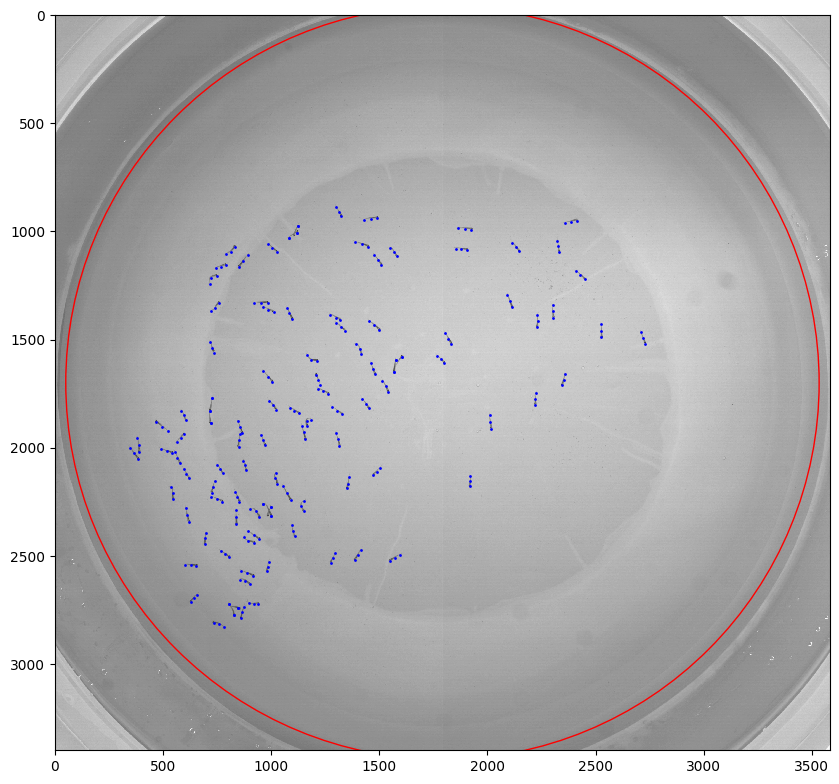

In [1]:
import numpy as np
import matplotlib.pyplot as plt
DATA_NAME='100_2'
vid=np.load('data_video/'+str(DATA_NAME)+'.npy')
midline=np.load('data_midline/'+str(DATA_NAME)+'_consistent.npy')
DATA_circle=np.load('data_circle/'+str(DATA_NAME)+'.npy')
#3584*3400
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(midline[0,:,0,0], midline[0,:,0,1], 'o', color='blue', markersize=1)
ax.plot(midline[0,:,1,0], midline[0,:,1,1], 'o', color='blue', markersize=1)
ax.plot(midline[0,:,2,0], midline[0,:,2,1], 'o', color='blue', markersize=1)
x,y,r=DATA_circle
circle=plt.Circle((x, y), r, color='r',fill=False)
ax.add_patch(circle)
ax.imshow(vid, interpolation='nearest')

In [2]:
import torch.nn as nn
import torch
import sys
import os
sys.path.append(os.path.join(os.getcwd(), 'code'))
from local_param import DiscreteImage,get_input_output
grid=64
R=300
scale=(grid//2)/R
batch_size=64

In [7]:
INPUT1, INPUT2, OUTPUT = get_input_output(midline[:10000], DATA_circle)

In [4]:
print(INPUT1.shape)
print(INPUT2.shape)
print(OUTPUT.shape)

(999900, 2)
(999900, 100, 7)
(999900, 6)


In [9]:
DATA_SIZE=INPUT1.shape[0]
NUM_EPOCH=40
NUM_BATCH=DATA_SIZE//batch_size
np.random.seed(0)
torch.manual_seed(0)
NUM_FISH=midline.shape[1]

In [3]:
from Resnet import ResNet18,train_model,test_model
model = ResNet18(in_channels=grid,num_channel=4).to('cuda')

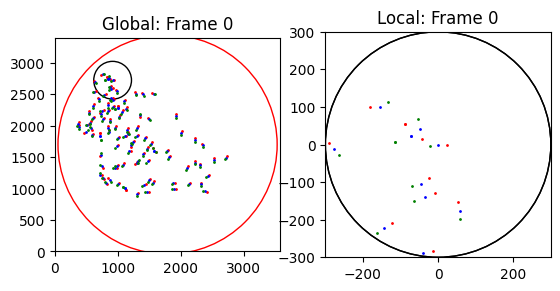

In [7]:
from animate import Global_Local_animate
TEMP1=INPUT1.reshape(-1,NUM_FISH,2)
TEMP2=INPUT2.reshape(-1,NUM_FISH,NUM_FISH,7)
ani=Global_Local_animate(midline,TEMP2[:100,0,:,0],TEMP2[:100,0,:,1],TEMP2[:100,0,:,2],TEMP1[:100,:,0],TEMP1[:100,:,1],TEMP2[:100,:,:,3],TEMP2[:100,:,:,4],TEMP2[:100,:,:,5].astype(bool),TEMP2[:100,:,:,6],vid=vid,DATA_circle=DATA_circle,R=R)

In [8]:
from IPython.display import HTML
HTML(ani.to_jshtml())

CNN

TODO FIX INPUT2 as L1 should also (2,3) shape

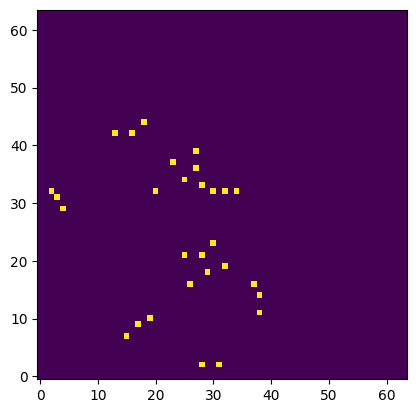

In [12]:
i=0
image=DiscreteImage(INPUT2[i,:,0],INPUT2[i,:,1],INPUT2[i,:,2],INPUT1[i,0],INPUT1[i,1],INPUT2[i,:,3],INPUT2[i,:,4],INPUT2[i,:,5].astype(bool),INPUT2[i,:,6],grid=grid,R=R,r=r)
fig,ax=plt.subplots()
ax.imshow(image.sum(axis=0))
ax.invert_yaxis()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm  # For progress bars
model,train_losses=train_model(model, INPUT1,INPUT2,OUTPUT, NUM_BATCH,DATA_SIZE,batch_size,NUM_EPOCH,grid,r=r,R=R)

cuda


Epoch 1/40 [Train]:   0%|          | 0/15623 [00:00<?, ?it/s]

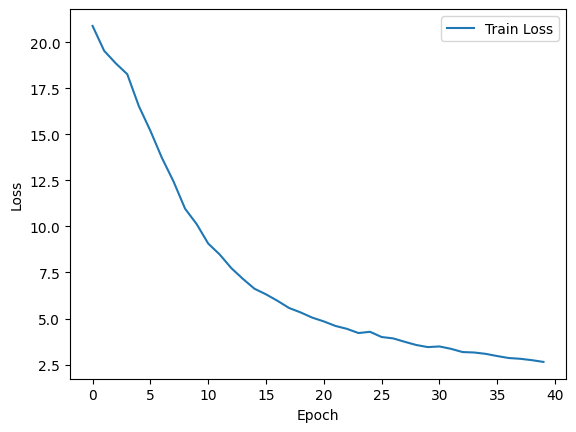

In [11]:
plt.plot(train_losses,label='Train Loss')
#plt.plot(test_losses,label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
torch.save(model.state_dict(), 'Model/'+str(DATA_NAME)+'Resnet_2.pt')

In [ ]:
model.load_state_dict(torch.load('Model/'+str(DATA_NAME)+'Resnet_2.pt'))

/tmp/ipykernel_1253558/3394965873.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('Model/'+str(DATA_NAME)+'Resnet_1.pt'))


<All keys matched successfully>

In [ ]:
from tqdm import tqdm
Test_frame=100
test_midline=test_model(model=model, initial_midline=midline[0], Test_frame=Test_frame, DATA_circle=DATA_circle, R=R, grid=grid,  bool_have_wall=True)


In [ ]:
ani.save("animation/2_wall.mp4", writer="ffmpeg")

(2,)


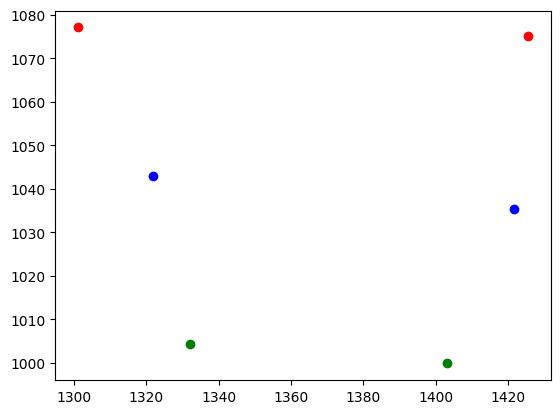

In [ ]:
body1=np.random.randint(low=vid.shape[1]//2, high=3*vid.shape[1]//2,size=2)
initialtheta=2*np.pi*np.random.rand(2)
initialphi=np.pi/6*np.random.rand(2)
initialalpha=2*np.pi*np.random.rand()
head1=40*np.array([np.cos(initialtheta[0]),np.sin(initialtheta[0])])+body1
tail1=40*np.array([np.cos(initialtheta[0]+np.pi-initialphi[0]),np.sin(initialtheta[0]+np.pi-initialphi[0])])+body1
body2=100*np.array([np.cos(initialalpha),np.sin(initialalpha)])+body1
head2=40*np.array([np.cos(initialtheta[1]),np.sin(initialtheta[1])])+body2
tail2=40*np.array([np.cos(initialtheta[1]+np.pi-initialphi[1]),np.sin(initialtheta[1]+np.pi-initialphi[1])])+body2
rand_midline=np.zeros((2,3,2))
print(np.array([np.cos(initialalpha),np.sin(initialalpha)]).shape)
rand_midline[0]=np.array([head1,body1,tail1])
rand_midline[1]=np.array([head2,body2,tail2])
plt.scatter(rand_midline[:,0,0], rand_midline[:,0,1], color='red')
plt.scatter(rand_midline[:,1,0], rand_midline[:,1,1], color='blue')
plt.scatter(rand_midline[:,2,0], rand_midline[:,2,1], color='green')

In [ ]:
ani.save("animation/2_no_wall_random.mp4", writer="ffmpeg")